# MLP Inverse Model — New Dataset
**Inputs (11 features):** 4 raw KPIs + 5 new statistical KPIs + 2 interaction terms  
**Outputs (3 parameters):** `RSSI_INFLECTION_POINT`, `PATH_LOSS_EXPONENT`, `AWGN_SIGMA`  
**Dropped:** `TRANSMITTING_RANGE` (fixed at 100m), `RX_SENSITIVITY_DBM` (constant)

## 0. Install Dependencies

In [1]:
pip install torch scikit-learn pandas numpy matplotlib joblib --break-system-packages

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: D:\rahma\PFE\Work\backup\home_backup_20260724\Calibration models\.venv\Scripts\python.exe -m pip install --upgrade pip


## 1. Imports & Config

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import warnings
warnings.filterwarnings('ignore')

# ── CHANGE THIS ──────────────────────────────
CSV_PATH = 'data/dataset09.1.csv'
# ─────────────────────────────────────────────

# Raw KPIs
RAW_COLS = [
    'mean_rssi_dbm','std_rssi_dbm', 'min_rssi_dbm',
    'loss_rate_pct', 'throughput_pkt_s',
    'mean_delay_s',  'std_delay_s',
    'std_loss_rate', 'per_node_min_prr',
]

# Final feature list (raw + interaction terms)
FEATURE_COLS = RAW_COLS + [
    'rssi_x_loss',
    'throughput_per_loss',
]

TARGET_COLS = ['RSSI_INFLECTION_POINT', 'PATH_LOSS_EXPONENT', 'AWGN_SIGMA']

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'Features : {len(FEATURE_COLS)}')
print(f'Targets  : {len(TARGET_COLS)}')

Using device: cpu
Features : 11
Targets  : 3


## 2. Load & Prepare Data

In [29]:
df = pd.read_csv(CSV_PATH)
print(f'Dataset: {df.shape[0]} rows × {df.shape[1]} columns')

# ── Handle NaNs ──────────────────────────────────────────────────────────
# RSSI features are NaN when loss_rate=100% (no packets received → no signal)
# Fill with -100 dBm sentinel (below sensitivity threshold)
nan_count = df[['mean_rssi_dbm', 'std_rssi_dbm', 'min_rssi_dbm']].isnull().sum()
print(f'NaN rows in RSSI features: {nan_count.max()} → filling with sentinel values')
df['mean_rssi_dbm'] = df['mean_rssi_dbm'].fillna(-100.0)
df['std_rssi_dbm']  = df['std_rssi_dbm'].fillna(0.0)    # no spread when no signal
df['min_rssi_dbm']  = df['min_rssi_dbm'].fillna(-100.0)

# ── Interaction terms ─────────────────────────────────────────────────────
df['rssi_x_loss']        = df['mean_rssi_dbm'] * df['loss_rate_pct']
df['throughput_per_loss'] = df['throughput_pkt_s'] / (df['loss_rate_pct'] + 1e-6)

print(f'Missing values after fill: {df[FEATURE_COLS].isnull().sum().sum()}')
display(df[FEATURE_COLS + TARGET_COLS].describe().round(4))

# ── Balance dataset by loss rate bin ─────────────────────────────────────
# The 0-1% loss bin has 6048 rows (69%) but they're non-identifiable
# (all parameter combinations produce near-zero loss → same KPIs)
# Fix: keep max 400 rows per loss bin so all regions are equally represented
 
'''MAX_PER_BIN = 400

bins   = [0, 1, 5, 10, 25, 50, 75, 101]
labels = ['0-1%','1-5%','5-10%','10-25%','25-50%','50-75%','75-100%']

df['loss_bin'] = pd.cut(df['loss_rate_pct'], bins=bins, labels=labels)

balanced = []
for label in labels:
    subset = df[df['loss_bin'] == label]
    kept   = subset.sample(min(len(subset), MAX_PER_BIN), random_state=42)
    balanced.append(kept)
    print(f'  {label:<10}: {len(subset):>5} → {len(kept):>5} rows')

df = pd.concat(balanced).drop(columns=['loss_bin']).reset_index(drop=True)
print(f'\nDataset: {len(df)} rows (was {8721})') 
'''

Dataset: 8940 rows × 15 columns
NaN rows in RSSI features: 658 → filling with sentinel values
Missing values after fill: 0


,mean_rssi_dbm,std_rssi_dbm,min_rssi_dbm,loss_rate_pct,throughput_pkt_s,mean_delay_s,std_delay_s,std_loss_rate,per_node_min_prr,rssi_x_loss,throughput_per_loss,RSSI_INFLECTION_POINT,PATH_LOSS_EXPONENT,AWGN_SIGMA
count,8940.0000,8940.0000,8940.0000,8940.0000,8940.0000,8940.0000,8940.0000,8940.0000,8940.0000,8940.0000,8940.0000,8940.0000,8940.0000,8940.0000
mean,-57.7522,7.7988,-83.6757,33.1629,80.2415,1.1996,0.5343,5.5334,0.5862,-2326.5225,22.8389,-75.0168,2.9980,7.6931
std,20.3844,4.2650,17.0980,39.2355,47.1035,1.3817,0.5159,6.0809,0.3867,3184.0532,25.7349,27.0717,1.2156,4.1286
min,-100.0000,0.0000,-100.0000,0.5800,0.0000,0.0000,0.0000,0.0000,0.0000,-10000.0000,0.0000,-120.0000,1.0000,1.0000
25%,-73.2200,4.5678,-100.0000,3.2400,30.1125,0.4390,0.2486,1.3230,0.1255,-4198.0506,0.4020,-100.0000,2.0000,4.0000
50%,-56.0450,7.9021,-88.0000,7.3100,111.3000,0.4905,0.3036,3.7634,0.8072,-370.2891,15.2111,-75.0000,3.0000,7.5000
75%,-41.3475,11.2084,-71.0000,74.9125,116.1700,1.3514,0.7013,7.5531,0.9202,-150.5661,35.8842,-50.0000,4.0000,11.0000
max,-24.4700,23.0963,-36.0000,100.0000,119.4500,9.4712,4.6062,44.7413,0.9924,-19.2096,205.9479,-30.0000,5.0000,23.0000


"MAX_PER_BIN = 400\n\nbins   = [0, 1, 5, 10, 25, 50, 75, 101]\nlabels = ['0-1%','1-5%','5-10%','10-25%','25-50%','50-75%','75-100%']\n\ndf['loss_bin'] = pd.cut(df['loss_rate_pct'], bins=bins, labels=labels)\n\nbalanced = []\nfor label in labels:\n    subset = df[df['loss_bin'] == label]\n    kept   = subset.sample(min(len(subset), MAX_PER_BIN), random_state=42)\n    balanced.append(kept)\n    print(f'  {label:<10}: {len(subset):>5} → {len(kept):>5} rows')\n\ndf = pd.concat(balanced).drop(columns=['loss_bin']).reset_index(drop=True)\nprint(f'\nDataset: {len(df)} rows (was {8721})') \n"

## 3. Train / Test Split & Scaling

In [30]:
X = df[FEATURE_COLS].values
y = df[TARGET_COLS].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train: {X_train.shape[0]}  |  Test: {X_test.shape[0]}')

# Scale inputs
X_scaler   = StandardScaler()
X_train_sc = X_scaler.fit_transform(X_train)
X_test_sc  = X_scaler.transform(X_test)

# Scale outputs
y_scaler   = StandardScaler()
y_train_sc = y_scaler.fit_transform(y_train)
y_test_sc  = y_scaler.transform(y_test)

# Tensors
X_train_t = torch.FloatTensor(X_train_sc).to(device)
y_train_t = torch.FloatTensor(y_train_sc).to(device)
X_test_t  = torch.FloatTensor(X_test_sc).to(device)
y_test_t  = torch.FloatTensor(y_test_sc).to(device)

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=64,
    shuffle=True
)

Train: 7152  |  Test: 1788


## 4. Model Architecture
**11 → 128 → 256 → 512 → 256 → 128 → 3**

In [31]:
class MLP(nn.Module):
    def __init__(self, input_dim=11, output_dim=3):
        super(MLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
                nn.BatchNorm1d(128),
                nn.ReLU(),
                nn.Dropout(0.1),

                nn.Linear(128, 256),
                nn.BatchNorm1d(256),
                nn.ReLU(),
                nn.Dropout(0.1),

                nn.Linear(256, 512),
                nn.BatchNorm1d(512),
                nn.ReLU(),
                nn.Dropout(0.1),

                nn.Linear(512, 256),
                nn.BatchNorm1d(256),
                nn.ReLU(),
                nn.Dropout(0.1),

                nn.Linear(256, 128),
                nn.BatchNorm1d(128),
                nn.ReLU(),
                nn.Dropout(0.05),

                nn.Linear(128, output_dim)
        )

    def forward(self, x):
        return self.network(x)


model = MLP(input_dim=11, output_dim=3).to(device)
print('Architecture: 11 → 128 → 256 → 512 → 256 → 128 → 3')
print(f'Total parameters: {sum(p.numel() for p in model.parameters()):,}')

Architecture: 11 → 128 → 256 → 512 → 256 → 128 → 3
Total parameters: 333,315


## 5. Training

In [32]:
EPOCHS              = 500
LR                  = 1e-3
EARLY_STOP_PATIENCE = 100
SEED = 123  
torch.manual_seed(SEED)
np.random.seed(SEED)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=40, factor=0.7
)

train_losses, val_losses = [], []
best_val_loss    = float('inf')
patience_counter = 0

print(f'Training (max {EPOCHS} epochs)...')
print(f'{"Epoch":<8} {"Train Loss":<14} {"Val Loss":<14} {"LR"}')
print('-' * 50)

for epoch in range(1, EPOCHS + 1):

    model.train()
    batch_losses = []
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(X_batch), y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        batch_losses.append(loss.item())

    train_loss = np.mean(batch_losses)

    model.eval()
    with torch.no_grad():
        val_loss = criterion(model(X_test_t), y_test_t).item()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'mlp_best.pt')
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch % 20 == 0 or epoch == 1:
        lr_now = optimizer.param_groups[0]['lr']
        print(f'{epoch:<8} {train_loss:<14.6f} {val_loss:<14.6f} {lr_now:.2e}')

    if patience_counter >= EARLY_STOP_PATIENCE:
        print(f'\nEarly stopping at epoch {epoch}')
        break

print(f'\nBest validation loss: {best_val_loss:.6f}')
print(f'Best epoch           : {train_losses.index(min(train_losses))+1}')

Training (max 500 epochs)...
Epoch    Train Loss     Val Loss       LR
--------------------------------------------------
1        0.209063       0.137886       1.00e-03
20       0.144571       0.117833       1.00e-03
40       0.136524       0.113775       1.00e-03
60       0.131661       0.113516       1.00e-03
80       0.127987       0.112812       1.00e-03
100      0.120000       0.115419       1.00e-03
120      0.119021       0.112976       1.00e-03
140      0.120642       0.110073       1.00e-03
160      0.115808       0.109624       7.00e-04
180      0.114466       0.111147       7.00e-04
200      0.113400       0.110547       4.90e-04
220      0.110653       0.110458       4.90e-04
240      0.110809       0.114691       3.43e-04
260      0.109278       0.111066       3.43e-04
280      0.107890       0.112477       2.40e-04

Early stopping at epoch 292

Best validation loss: 0.108034
Best epoch           : 285


## 6. Training Curve

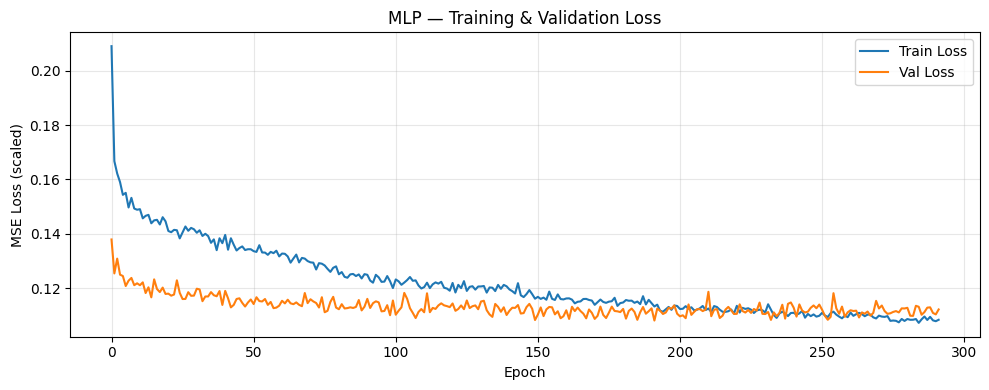

In [33]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train Loss', linewidth=1.5)
plt.plot(val_losses,   label='Val Loss',   linewidth=1.5)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss (scaled)')
plt.title('MLP — Training & Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('mlp_training_curve.png', dpi=150)
plt.show()

## 7. Evaluate on Test Set

In [34]:
model.load_state_dict(torch.load('mlp_best.pt'))
model.eval()

with torch.no_grad():
    y_pred_sc = model(X_test_t).cpu().numpy()

y_pred = y_scaler.inverse_transform(y_pred_sc)

print(f'{"Target":<30} {"MAE":>8} {"RMSE":>8} {"R²":>8}')
print('-' * 58)
results = {}
for i, col in enumerate(TARGET_COLS):
    mae  = mean_absolute_error(y_test[:, i], y_pred[:, i])
    rmse = np.sqrt(mean_squared_error(y_test[:, i], y_pred[:, i]))
    r2   = r2_score(y_test[:, i], y_pred[:, i])
    results[col] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    print(f'{col:<30} {mae:>8.4f} {rmse:>8.4f} {r2:>8.4f}')

Target                              MAE     RMSE       R²
----------------------------------------------------------
RSSI_INFLECTION_POINT            9.5294  13.5001   0.7565
PATH_LOSS_EXPONENT               0.1021   0.2002   0.9712
AWGN_SIGMA                       0.4307   0.8981   0.9528


## 8. Save Model & Scalers

In [15]:
torch.save(model.state_dict(), 'mlp11_sc3_model.pt')
joblib.dump(X_scaler, 'mlp11_x_sc3_scaler.pkl')
joblib.dump(y_scaler, 'mlp11_y_sc3_scaler.pkl')
print('Saved → mlp11_model.pt')
print('Saved → mlp11_x_scaler.pkl')
print('Saved → mlp11_y_scaler.pkl')

Saved → mlp11_model.pt
Saved → mlp11_x_scaler.pkl
Saved → mlp11_y_scaler.pkl


## 10. Predict from Real KPIs
Replace the values below with your real measurements from FIT IoT-LAB.  
Run `run_analysis.py` on your real `serial.log` to get these values.

In [16]:


# ── PASTE YOUR metrics.csv VALUES HERE ───────────
mean_rssi   = -75.24  # mean_rssi_dbm
std_rssi    =  23.2402  # std_rssi_dbm
min_rssi    = -91.0    # min_rssi_dbm
loss_rate   =  8.82  # loss_rate_pct
throughput  =   36.39 # throughput_pkt_s
mean_delay  =   0.505963  # mean_delay_s
std_delay   =   0.358582  # std_delay_s
std_loss    =   10.3277  # std_loss_rate
min_prr     =   0.7442    # per_node_min_prr
# ─────────────────────────────────────────────────


# Compute interaction terms — must match training exactly
rssi_x_loss        = mean_rssi  * loss_rate
throughput_per_loss = throughput / (loss_rate + 1e-6)

real_kpis = np.array([[
    mean_rssi, std_rssi, min_rssi,
    loss_rate, throughput,
    mean_delay, std_delay,
    std_loss, min_prr,
    rssi_x_loss,
    throughput_per_loss
]])

x_scaled = X_scaler.transform(real_kpis)
x_tensor = torch.FloatTensor(x_scaled).to(device)

model.eval()
with torch.no_grad():
    y_scaled = model(x_tensor).cpu().numpy()

params = y_scaler.inverse_transform(y_scaled)[0]

print('── Predicted Simulation Parameters ──────────────')
for name, val in zip(TARGET_COLS, params):
    print(f'  {name:<30}: {val:.4f}')
print('\n→ Plug these values into Cooja LogisticLoss settings')

── Predicted Simulation Parameters ──────────────
  RSSI_INFLECTION_POINT         : -77.7012
  PATH_LOSS_EXPONENT            : 2.9310
  AWGN_SIGMA                    : 7.5984

→ Plug these values into Cooja LogisticLoss settings
